<a href="https://colab.research.google.com/github/HunterL28/Alzheimer-sBioinformaticsProject/blob/main/Alzheimer's_scRNA_seq_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installing Packages**

In [ ]:
%pip install -q igraph==0.10.4 leidenalg==0.10.1 scanpy


# import packages
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import os

sc.settings.verbosity = 3   # verbosity: errors (0), warnings (1), info (2), hints (3)

# customize resolution and color of your figures
sc.settings.set_figure_params(dpi=80, figsize=(4,4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.1 MB/s eta 0:00:00


**Importing Data #1**

In [ ]:
# (!) Shell commands for creating folder and storing data

# Create a folder ()
!mkdir data
# Download count file from web (wget) and save to file named GSE138852_counts.csv.gz
!wget -O data/GSE138852_counts.csv.gz "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852_counts.csv.gz"
# Download covariates file from web (wget) and save to file named GSE138852_covariates.csv.gz
!wget -O data/GSE138852_covariates.csv.gz "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852%5Fcovariates.csv.gz"

--2025-10-28 18:51:26--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852_counts.csv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12466052 (12M) [application/x-gzip]
Saving to: ‘data/GSE138852_counts.csv.gz’

data/GSE138852_coun 100%[===================>]  11.89M  12.8MB/s    in 0.9s    

2025-10-28 18:51:27 (12.8 MB/s) - ‘data/GSE138852_counts.csv.gz’ saved [12466052/12466052]

--2025-10-28 18:51:27--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852%5Fcovariates.csv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86792 (85K) 

In [ ]:
# create a matrix of data 'counts' from compressed gzip file
counts = pd.read_csv("data/GSE138852_counts.csv.gz", index_col=0, compression='gzip')
covariates = pd.read_csv("data/GSE138852_covariates.csv.gz", index_col=0, compression='gzip')
print("Counts and Covariates loaded: \nCovariates shape (cells, conditions): ", covariates.shape, "\nCounts shape (genes, cells): ", counts.shape)

Counts and Covariates loaded: 
Covariates shape (cells, conditions):  (13214, 5) 
Counts shape (genes, cells):  (10850, 13214)


**Importing Example .txt Data**

In [ ]:
# @title
# Data upload and extraction using .txt
!mkdir data2
!wget -O data2/GSE285694_RAW.tar "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE285694&format=file"
!tar -xf data2/GSE285694_RAW.tar -C data2

counts1 = pd.read_csv("data2/GSM8706867_MAE1_S1_DGE.txt.gz", sep='\t', compression='gzip', index_col=0)
counts2 = pd.read_csv("data2/GSM8706868_MAE2_S2_DGE.txt.gz", sep='\t', compression='gzip', index_col=0)
print("Female Healthy (cells, genes) =", counts1.shape)
print("Female TG (cells, genes) =", counts2.shape)

In [ ]:
counts3 = pd.concat((counts1, counts2))
print(counts3.shape)
metadata = pd.DataFrame({"Label": (["Healthy"]*counts1.shape[0]
                         + ["TG"]*counts2.shape[0])}, index=counts3.index)
metadata.index.name = "Cell"
print(metadata.shape)
metadata.head(2)

**Importing Example .pkl File**

In [ ]:
# @title
!mkdir data3
!wget -O data3/GSE142267_RAW.tar "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE142267&format=file"
!tar -xf data3/GSE142267_RAW.tar -C data3

counts4 = pd.read_pickle("/content/data3/GSM4224436_TG1-APP-11M_mm38.pkl.gz")
print("counts (genes, cells) =", counts.shape)

**Cleaning Data**

In [ ]:
print(covariates.columns)
print(covariates['oupSample.subclustCond'].unique())
# Keep only AD and control cells
covariates = covariates[covariates['oupSample.subclustCond'].isin(['AD','ct'])]
# Update counts matrix to only keep cell IDs that match the cells in covariates
counts = counts.loc[:, covariates.index]
covariates.head(5)

Index(['oupSample.batchCond', 'oupSample.cellType',
       'oupSample.cellType_batchCond', 'oupSample.subclustID',
       'oupSample.subclustCond'],
      dtype='object')
['AD' 'ct' 'undetermined']


,oupSample.batchCond,oupSample.cellType,oupSample.cellType_batchCond,oupSample.subclustID,oupSample.subclustCond
AAACCTGGTAGAAAGG_AD5_AD6,AD,oligo,oligo_AD,o3,AD
AAACCTGGTAGCGATG_AD5_AD6,AD,oligo,oligo_AD,o3,AD
AAACCTGTCAGTCAGT_AD5_AD6,AD,oligo,oligo_AD,o3,AD
AAACCTGTCCAAACAC_AD5_AD6,AD,oligo,oligo_AD,o3,AD
AAACCTGTCCAGTATG_AD5_AD6,AD,oligo,oligo_AD,o3,AD


In [ ]:
# Always convert to sparse matrix with genes x cells (not needed here)
if counts.shape[0] < counts.shape[1]:
    # genes x cells -> transpose
    X = sparse.csr_matrix(counts.values.T)
    var_names = counts.index.astype(str).tolist()
    obs_names = counts.columns.astype(str).tolist()
else:
    X = sparse.csr_matrix(counts.values)
    var_names = counts.columns.astype(str).tolist()
    obs_names = counts.index.astype(str).tolist()
print("Updated sparese matrix with shape (cells, genes) =", X.shape, covariates.shape)

Updated sparese matrix with shape (cells, genes) = (12490, 10850) (12490, 5)


**Pre-Processing Data**

In [ ]:
# Create AnnData object
# AnnData expects X to be a cells x genes matrix
# obs is more information on each cell
# var is more information on each gene (leaving blank)
# Sample: adata = sc.AnnData(X, obs=pd.DataFrame(index=obs_names), var=pd.DataFrame(index=var_names))
adata = sc.AnnData(X, obs=covariates, var=pd.DataFrame(index=var_names))
print("AnnData created:", adata)

# Copy the raw AnnData so we can test different preprocessing pipelines
adata2 = adata.copy()

AnnData created: AnnData object with n_obs × n_vars = 12490 × 10850
    obs: 'oupSample.batchCond', 'oupSample.cellType', 'oupSample.cellType_batchCond', 'oupSample.subclustID', 'oupSample.subclustCond'


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:23)


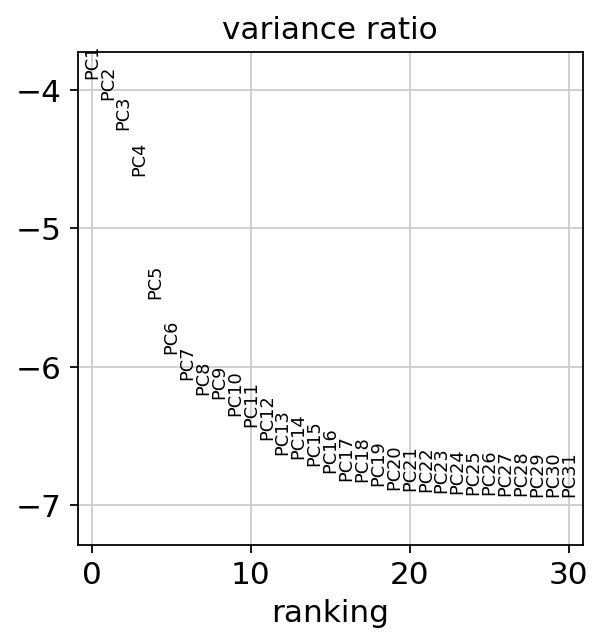

In [ ]:
# Preprocessing (using Scanpy pre-processing object pp)
sc.pp.filter_genes(adata, min_cells=3)     # drop very rare genes (in <3 cells), adds n_cells to var
sc.pp.filter_cells(adata, min_genes=200)  # filter cells
sc.pp.normalize_total(adata, target_sum=1e4) # sum of all genes in every cell is 1e4
sc.pp.log1p(adata) # Compress large values after normalization
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False) # adds highly_variable  means	dispersions	dispersions_norm to var
sc.pp.scale(adata, max_value=10) # z-score standardizing of genes (max gene # value = 10), adds mean  std to var
sc.tl.pca(adata, svd_solver='arpack') # Creates axis for clustering, SVD is rediculously smart statistics/mathematics
sc.pl.pca_variance_ratio(adata, log=True)

In [ ]:
# Viewing obs
adata.obs.head()

In [ ]:
sc.pl.violin(adata, ['oupSample.cellType','oupSample.cellType_batchCond', 'oupSample.subclustID'], jitter=0.3, multi_panel=True)

In [ ]:
gene_adata = sc.AnnData(adata.var)
sc.pl.violin(gene_adata, ['n_cells', 'mean'], jitter=0.3, multi_panel=True)

**Interactive Preprocessing**

computing PCA
    with n_comps=50
    finished (0:00:14)


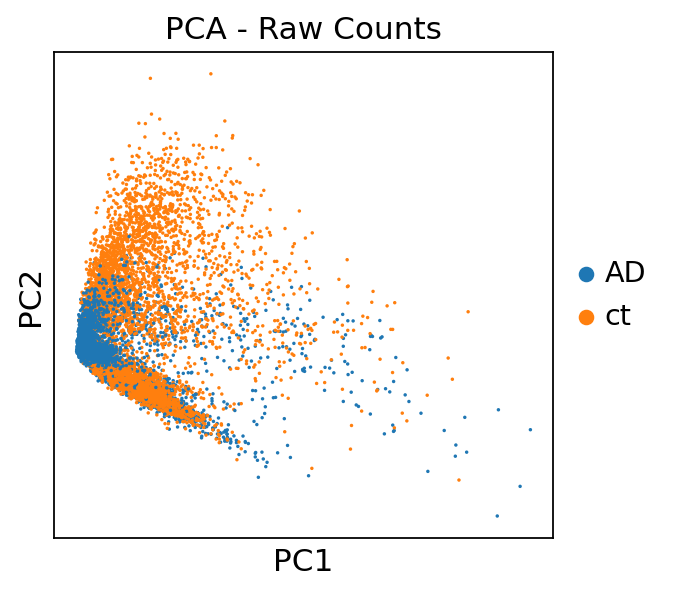

normalizing counts per cell
    finished (0:00:04)
computing PCA
    with n_comps=50
    finished (0:00:06)


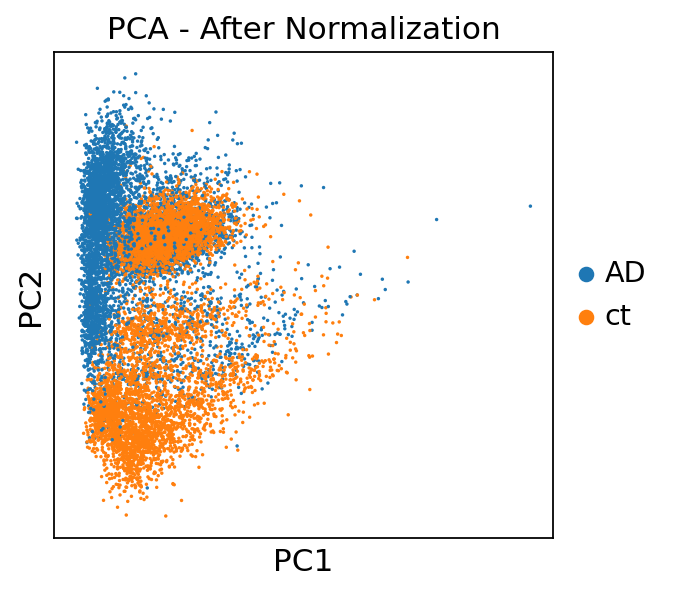

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:12)


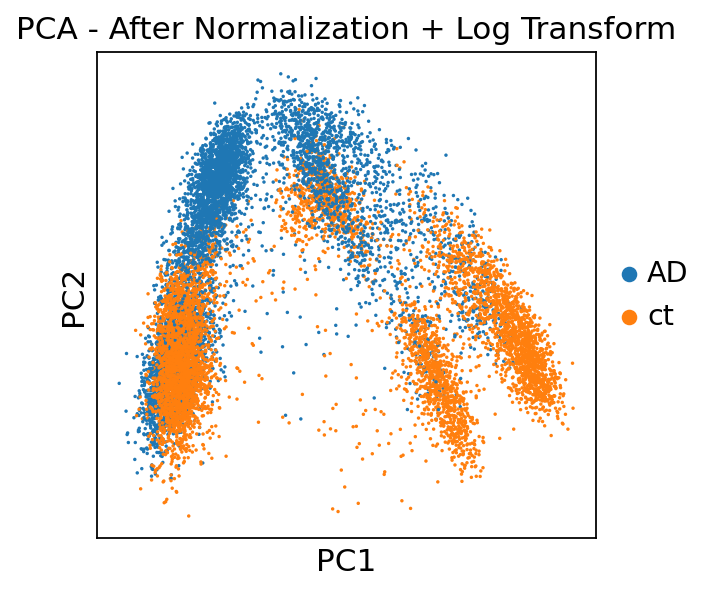

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:01)


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


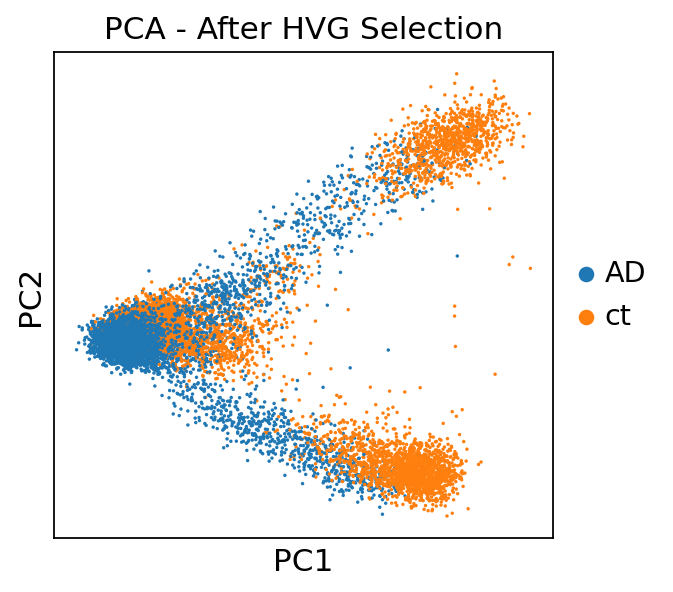

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:26)


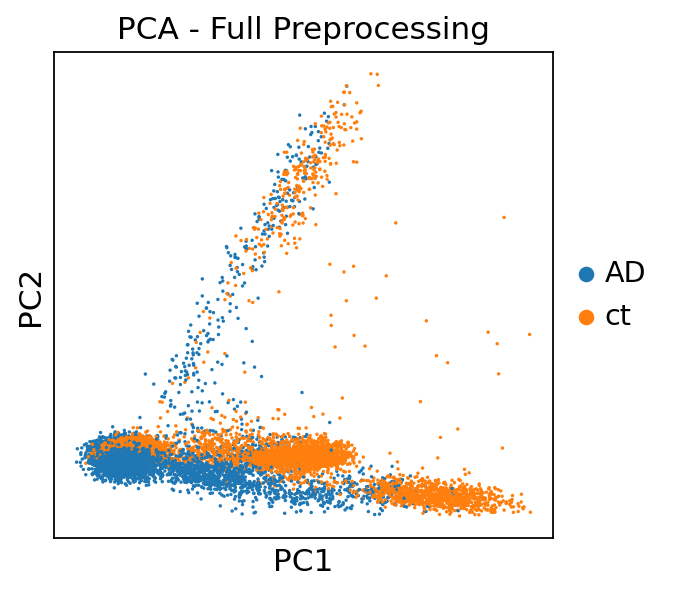

In [ ]:
mincells = 3 # Edit min cells value
mingenes = 1 # EDIT min_genes
targetsum = 1e4 # EDIT target_sum
HVGnum = 2000 # Edit numbertop genes of
MaxScaleValue = 10 # Edit max scale value

### 1. PCA on raw counts (no preprocessing yet)
adata_raw = adata2.copy()
sc.tl.pca(adata_raw, svd_solver='arpack')
sc.pl.pca(adata_raw, color='oupSample.subclustCond', title="PCA - Raw Counts")

### 2. Normalization only
adata_norm = adata2.copy()
sc.pp.filter_genes(adata_norm, min_cells=mincells)
sc.pp.filter_cells(adata_norm, min_genes=mingenes)
sc.pp.normalize_total(adata_norm, target_sum=targetsum)
sc.tl.pca(adata_norm, svd_solver='arpack')
sc.pl.pca(adata_norm, color='oupSample.subclustCond', title="PCA - After Normalization")

### 3. Normalization + log transform
adata_log = adata2.copy()
sc.pp.filter_genes(adata_log, min_cells=mincells)
sc.pp.filter_cells(adata_log, min_genes=mingenes)
sc.pp.normalize_total(adata_log, target_sum=targetsum)
sc.pp.log1p(adata_log)
sc.tl.pca(adata_log, svd_solver='arpack')
sc.pl.pca(adata_log, color='oupSample.subclustCond', title="PCA - After Normalization + Log Transform")

### 4. Add HVG filtering
adata_hvg = adata2.copy()
sc.pp.filter_genes(adata_hvg, min_cells=mincells)
sc.pp.filter_cells(adata_hvg, min_genes=mingenes)
sc.pp.normalize_total(adata_hvg, target_sum=targetsum)
sc.pp.log1p(adata_hvg)
sc.pp.highly_variable_genes(adata_hvg, n_top_genes=HVGnum)
adata_hvg = adata_hvg[:, adata_hvg.var['highly_variable']]  # keep only HVGs
sc.tl.pca(adata_hvg, svd_solver='arpack')
sc.pl.pca(adata_hvg, color='oupSample.subclustCond', title="PCA - After HVG Selection")

### 5. Full preprocessing pipeline (scaling included)
adata_full = adata2.copy()
sc.pp.filter_genes(adata_full, min_cells=mincells)
sc.pp.filter_cells(adata_full, min_genes=mingenes)
sc.pp.normalize_total(adata_full, target_sum=targetsum)
sc.pp.log1p(adata_full)
sc.pp.highly_variable_genes(adata_full, n_top_genes=HVGnum)
adata_full = adata_full[:, adata_full.var['highly_variable']]
sc.pp.scale(adata_full, max_value=MaxScaleValue)
sc.tl.pca(adata_full, svd_solver='arpack')
sc.pl.pca(adata_full, color='oupSample.subclustCond', title="PCA - Full Preprocessing")

In [ ]:
# Creating two adata objects for final analysis where clustering is split by subgroup
adata_ad = adata[adata.obs['oupSample.batchCond'] == 'AD'].copy()
adata_ct = adata[adata.obs['oupSample.batchCond'] == 'ct'].copy()

**Clustering**

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


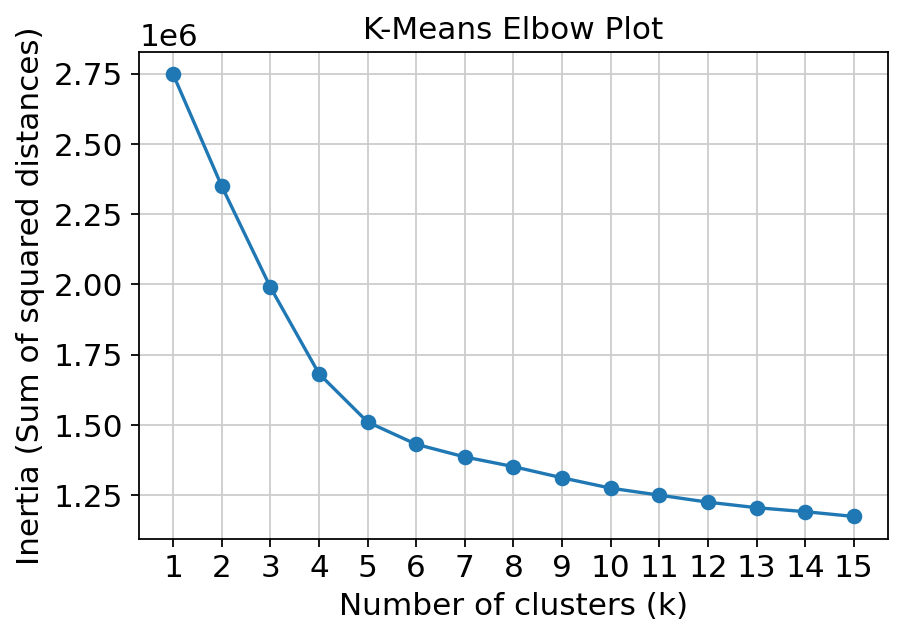

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate K-Means plots of different k values
inertia = []
k_values = range(1, 16)

for k in k_values:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=20)
    kmeans.fit(adata.obsm['X_pca'])
    inertia.append(kmeans.inertia_)  # sum of squared distances to cluster centers

# Create Elbow Plot
plt.figure(figsize=(6,4))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('K-Means Elbow Plot')
plt.xticks(k_values)
plt.grid(True)
plt.show()

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:24)
running Louvain clustering
    finished: found 12 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering


/tmp/ipython-input-606200302.py:12: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0, key_added='leiden', random_state=0)


    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


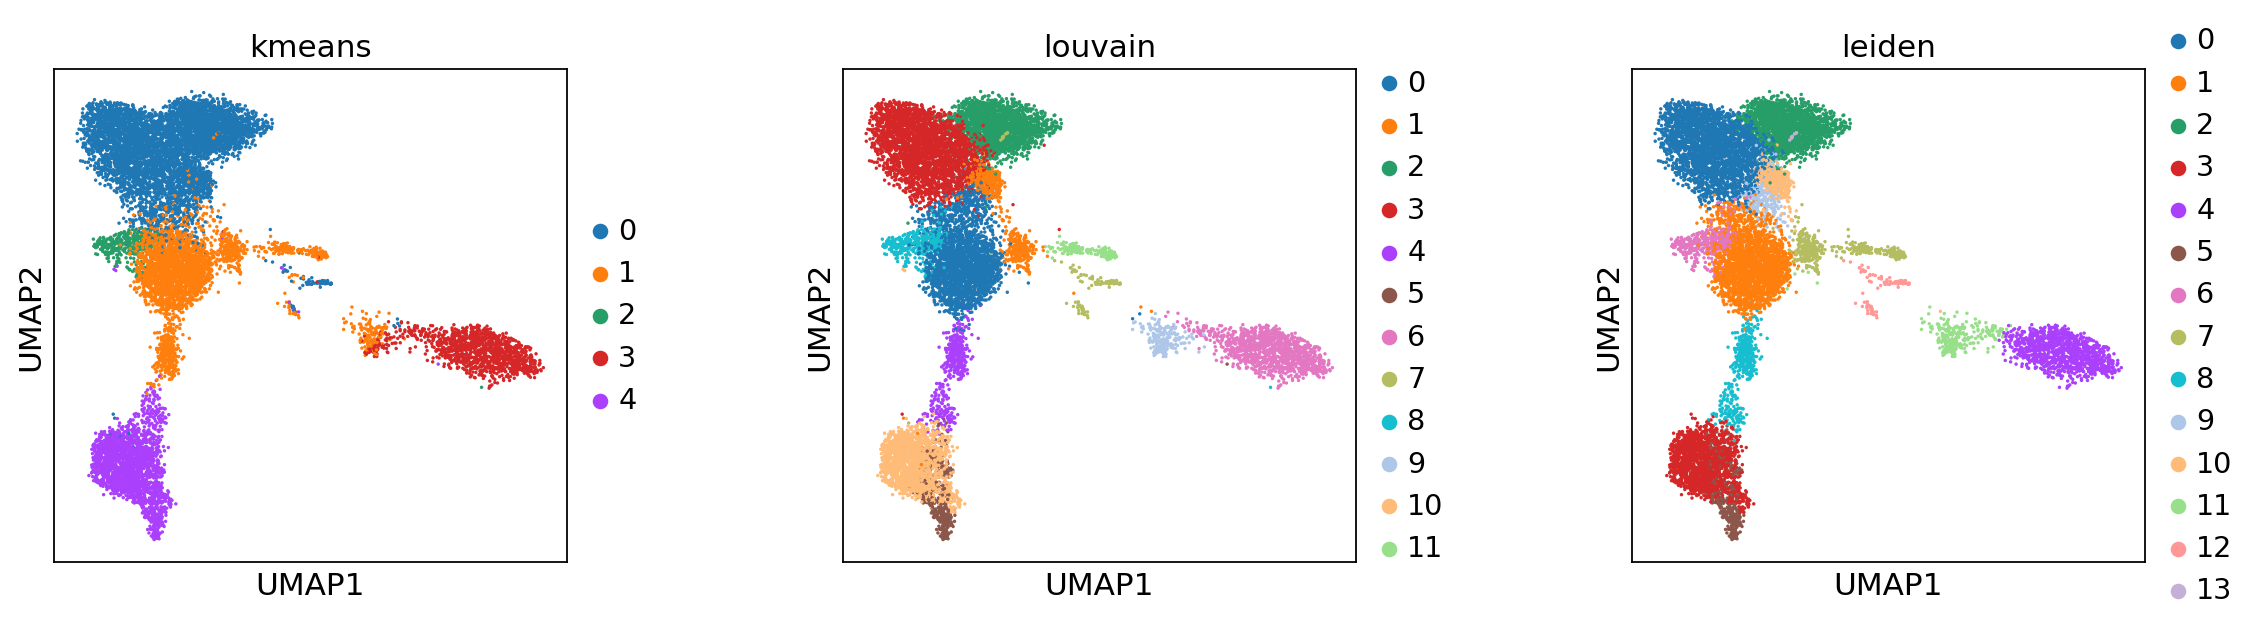

In [ ]:
#K-Means Clustering
kmeans = KMeans(n_clusters=5, n_init=50, random_state=0)
adata.obs['kmeans'] = kmeans.fit_predict(adata.obsm['X_pca']).astype(str)

# Build k-NN graph first
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')

# Run Louvain
sc.tl.louvain(adata, resolution=1.0, key_added='louvain', random_state=0, flavor='igraph')

# Run Leiden
sc.tl.leiden(adata, resolution=1.0, key_added='leiden', random_state=0)

# Compare Results
# Compute UMAP embedding
sc.tl.umap(adata, n_components=3)
sc.pl.umap(adata, color=['kmeans', 'louvain', 'leiden'], wspace=0.4)

**Data Visualization**

In [ ]:
# Getting the most common genes from the subsample
gene_totals = np.array(adata.X.sum(axis=0)).flatten() # Create 1-D array of summed gene values across all cells

top_genes = pd.DataFrame({'gene': adata.var_names, 'total_counts': gene_totals}).sort_values('total_counts', ascending=False).head(16)['gene'].tolist()

print("Top 16 most highly expressed genes:", top_genes)
sc.pl.umap(adata, color=top_genes, wspace=0.4)

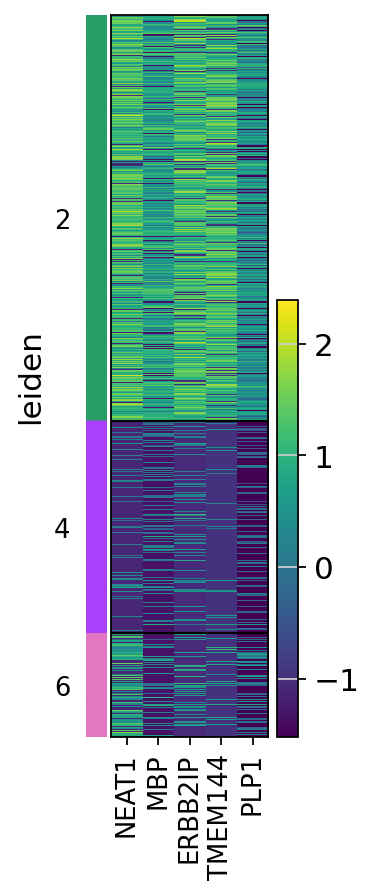

In [ ]:
# Create a heatmap showing how much each cell in specific Leiden clusters express chosen genes
sc.pl.heatmap(
    adata[adata.obs['leiden'].isin(['2','4','6'])],   # subset to cluster(s)
    var_names=['NEAT1', 'MBP', 'ERBB2IP', 'TMEM144', 'PLP1'],
    groupby='leiden',
    use_raw=False,
    cmap='viridis')

In [ ]:
# @title
# More advanced plotting using UMAP and Matplotlib
import matplotlib.pyplot as plt


umap = adata.obsm['X_umap'][:, 0:3] # Take first 3 UMAP axes
leiden = adata.obs['leiden'] # Take Leiden clusted column from adata.obs

# Create a scatter (dot plot) of your cells according to PCA values
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d') # 3-D plot
scatter = ax.scatter(umap[:,0], umap[:,1], umap[:,2], c=leiden.cat.codes, cmap='tab20') # .cat.codes converts Leiden string values to integers, 'tab20' sets color

# Centering x, Y, and Z axis
x_center = (umap[:,0].max() + umap[:,0].min())/2
y_center = (umap[:,1].max() + umap[:,1].min())/2
z_center = (umap[:,2].max() + umap[:,2].min())/2

# Create visual axis lines
ax.plot([x_center,x_center], [y_center,y_center], [umap[:,2].min() - 2, umap[:,2].max() + 2], c = 'k', lw = 5)
ax.plot([x_center,x_center], [umap[:,1].min() - 2, umap[:,1].max() + 2], [z_center,z_center], c = 'k', lw = 5)
ax.plot([umap[:,0].min() - 2, umap[:,0].max() + 2], [y_center,y_center], [z_center,z_center], c = 'k', lw = 5)

# Set viewing elevation and angle (Edit)
ax.view_init(elev=25, azim=10)

ax.axis('off')

plt.show()

In [ ]:
# @title
import plotly.express as px

fig = px.scatter_3d(
    pd.DataFrame(
    adata.obsm['X_umap'][:, 0:3],
    columns=['UMAP1', 'UMAP2', 'UMAP3']),
    x= 'UMAP1', y= 'UMAP2', z= 'UMAP3',
    color= adata.obs['leiden'],
    title='3D UMAP Plot (colored by Leiden clusters)',
)

fig.update_traces(marker_size=4)
fig.show()


**Assigning Marker Genes**

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


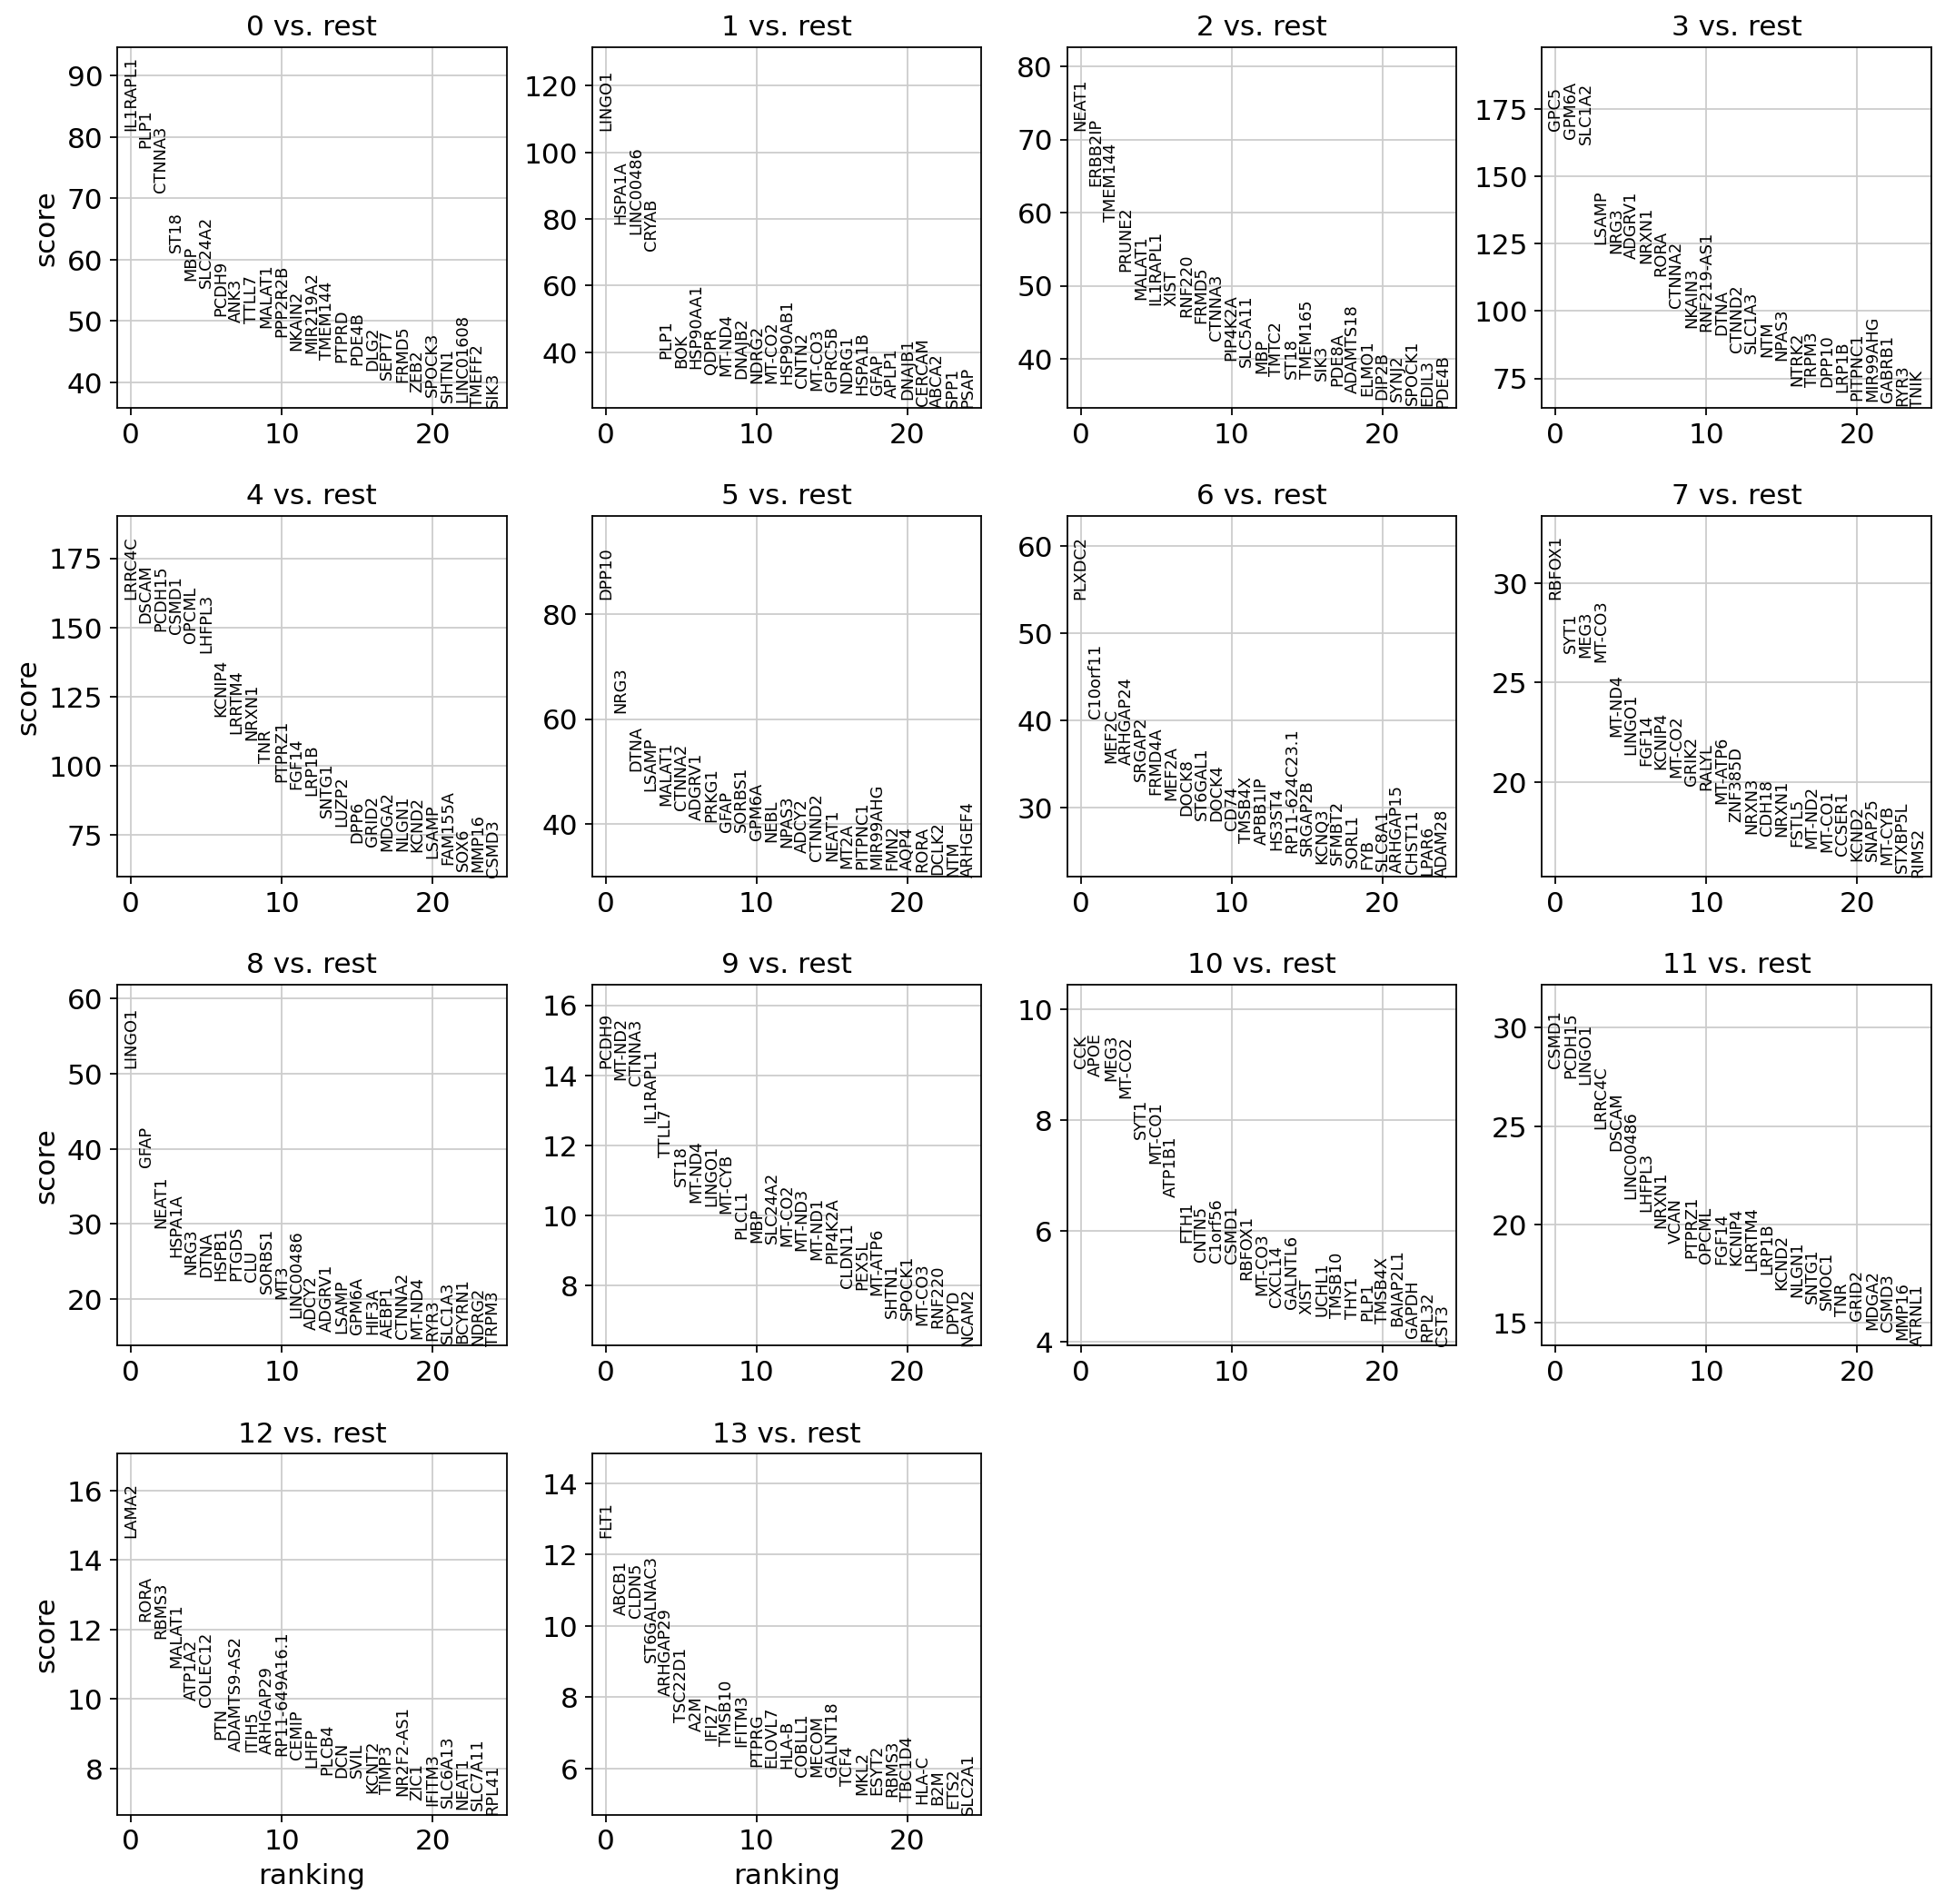

In [ ]:
# Rank marker genes per cluster
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',    # column in adata.obs with cluster labels
    method='t-test',     # 't-test', 'wilcoxon', or 'logreg'
    use_raw = True
)

# See top 25 genes per cluster
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [ ]:
adata.uns['rank_genes_groups'] # This is rank_genes_groups creates... its pretty messy but contains valuable information

In [ ]:
# Take the top gene expressed in every subgroup and display which cells express it the most
# This is a basic check to visualize how well clusters capture subsets of cell types
df = sc.get.rank_genes_groups_df(adata, None)
top_genes = df.groupby("group").head(1)['names'].unique().tolist()  # pick top gene per cluster (head(1))
sc.pl.umap(adata, color=top_genes, wspace=0.4)

In [ ]:
sc.get.rank_genes_groups_df(adata, None) # Ranks every gene by how well its expressed in every group using test method specified above

In [ ]:
sc.get.rank_genes_groups_df(adata, None).groupby("group").head(5) # Building on the previous code block, this shows the top 5 expressed genes per cluster (group) as a DataFrame

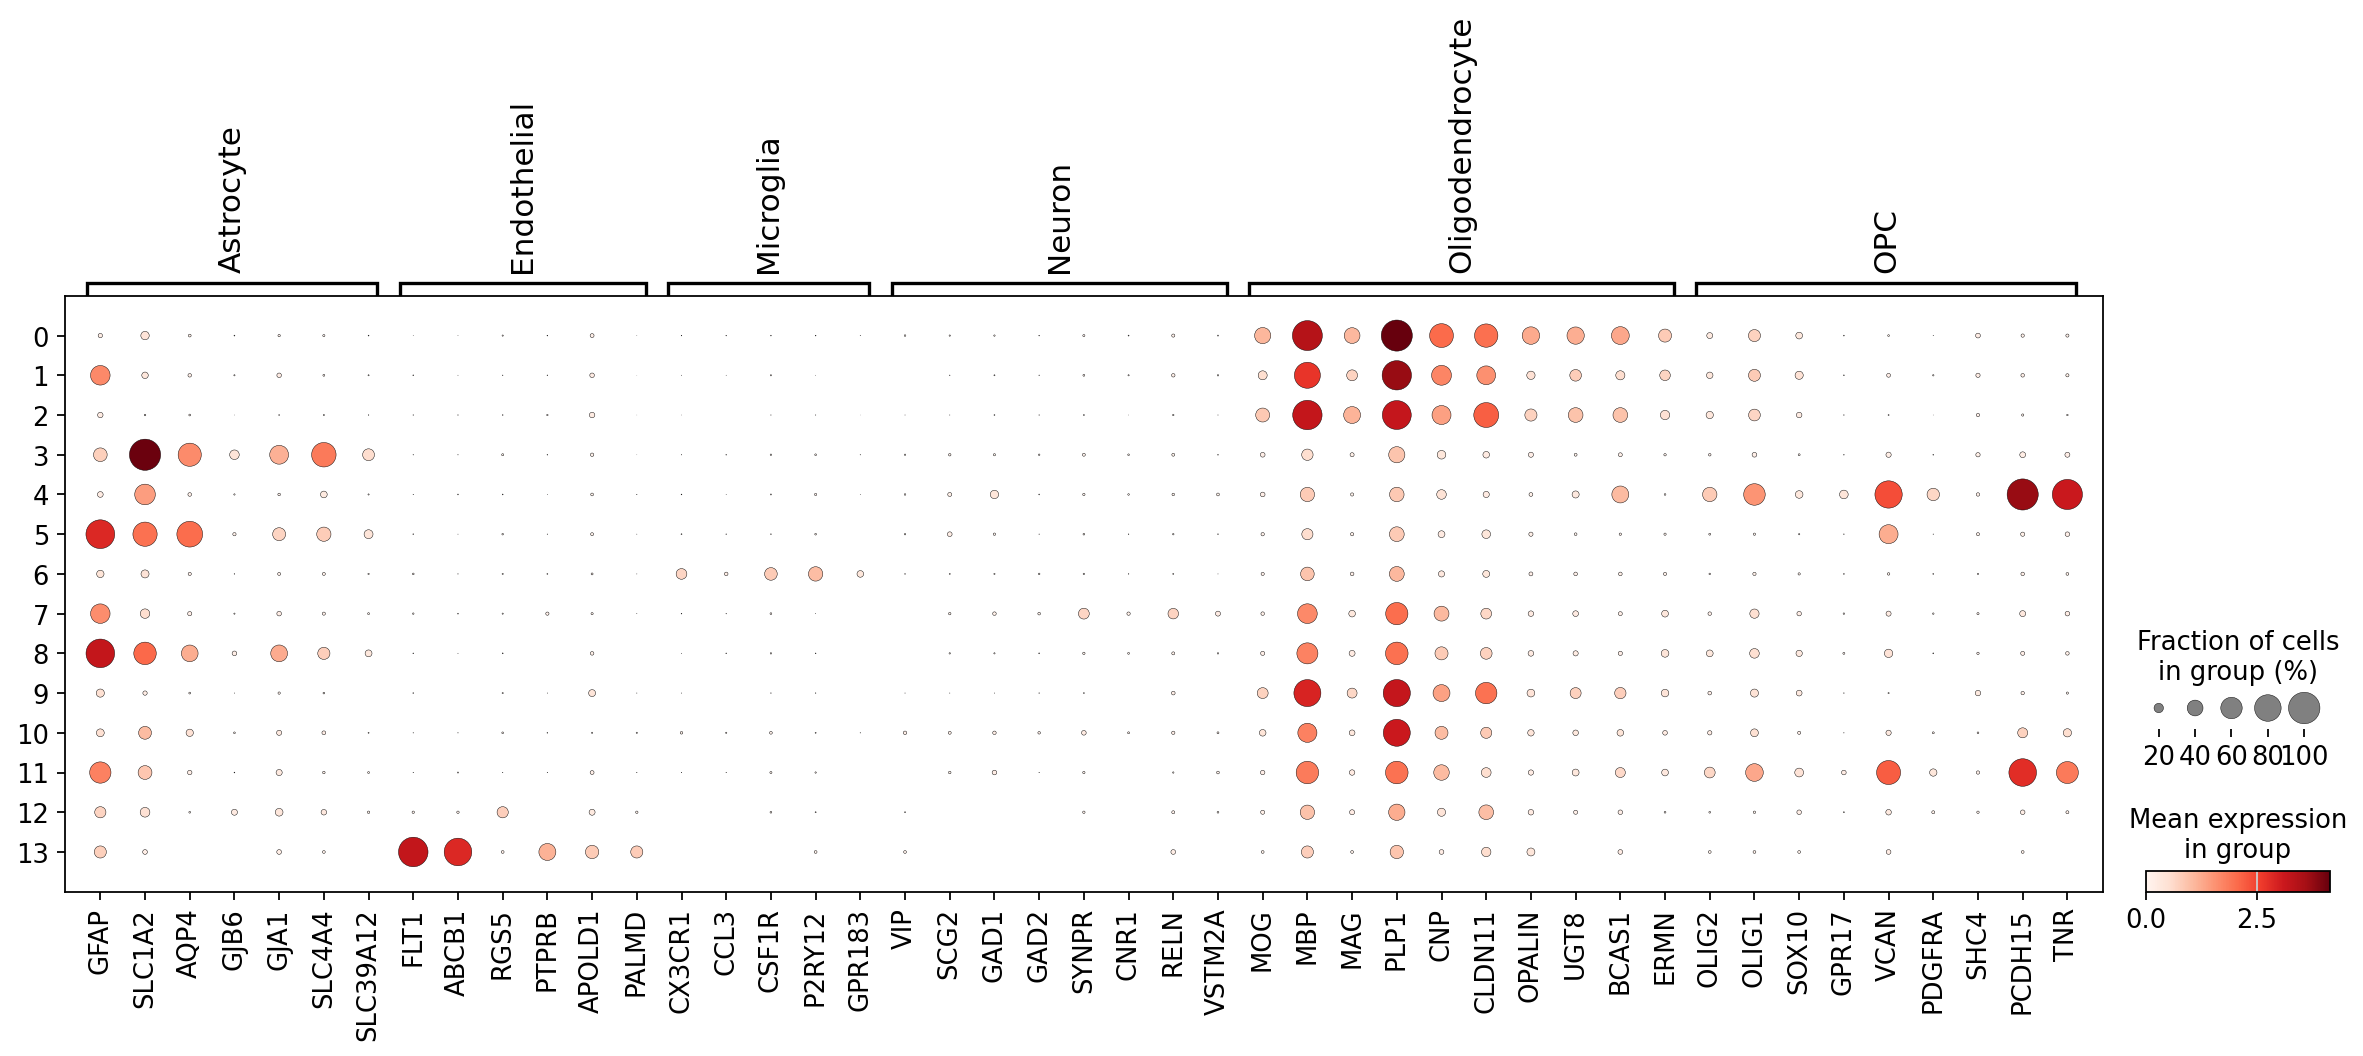

In [ ]:
# Creating a dot plot to identify likely cell types of each cluster

# Common marker genes of specific brain cell types. Information taken from https://www.nature.com/articles/s41598-018-27293-5/figures/4
markers = {
    'Astrocyte': ['GFAP', 'SLC1A2', 'AQP4', 'GJB6', 'GJA1', 'SLC4A4', 'SLC39A12'],
    'Endothelial': ['FLT1', 'ABCB1', 'RGS5', 'PTPRB', 'APOLD1', 'PALMD'],
    'Microglia': ['CX3CR1', 'CCL3', 'CSF1R', 'P2RY12', 'GPR183'],
    'Neuron': ['VIP', 'SCG2', 'GAD1', 'GAD2', 'SYNPR', 'CNR1', 'RELN', 'VSTM2A'],
    'Oligodendrocyte': ['MOG', 'MBP', 'MAG', 'PLP1', 'CNP', 'CLDN11', 'OPALIN', 'UGT8', 'BCAS1', 'ERMN'],
    'OPC': ['OLIG2', 'OLIG1', 'SOX10', 'GPR17', 'VCAN', 'PDGFRA', 'SHC4', 'PCDH15', 'TNR']
}

# Manually inputed cell types for every cluster
cluster_labels = {
    '0': 'Oligodendrocyte',
    '1': 'Oligodendrocyte',
    '2': 'Oligodendrocyte',
    '3': 'Astrocyte',
    '4': 'OPC',
    '5': 'Astrocyte',
    '6': 'Microglia',
    '7': 'Oligodendrocyte',
    '8': 'Astrocyte',
    '9': 'Oligodendrocyte',
    '10': 'Oligodendrocyte',
    '11': 'OPC',
    '12': 'Oligodendrocyte',
    '13': 'Endothelial'
}

# Creating new adata.obs category mapping leiden values to corresponding cluster_labels
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_labels)

# Creating dot plot
sc.pl.dotplot(adata, markers, groupby='leiden')

In [ ]:
# @title
results = adata.uns['rank_genes_groups']
out = np.array([[0, 0, 0, 0, 0]])
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((
            results['names'][group],
            results['scores'][group],
            results['pvals_adj'][group],
            results['logfoldchanges'][group],
            np.array([group] * len(results['names'][group]))
        )).astype('object').T
    ))

markers = pd.DataFrame(out[1:], columns=['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])
markers = markers[(markers.pval_adj < 0.05) & (markers.lfc > 1)]
print(markers.shape)
markers

**Final Analysis**

In [ ]:
# Creating a pandas crosstab object with clusters, corresponding cell types, and ratio of subgroups within each
pd.crosstab(
    index=[adata.obs['leiden'], adata.obs['cell_type']],
    columns=adata.obs['oupSample.batchCond']
)

,oupSample.batchCond,AD,ct
leiden,cell_type,,
0,Oligodendrocyte,108,2595
1,Oligodendrocyte,2239,11
2,Oligodendrocyte,2018,29
3,Astrocyte,19,1427
4,OPC,129,944
5,Astrocyte,253,273
6,Microglia,222,303
7,Oligodendrocyte,363,91
8,Astrocyte,428,4


In [ ]:
# Running t-tests between subgroups within a cluster
# SIGNIFICANT IF pval < 0.05
# Negative t_stat means more prevalent in ct
from scipy.stats import ttest_ind

cluster_number = '0' # Choosing cluster 0
adata_ct = adata[adata.obs['leiden'] == cluster_number].copy() # Grabbing a copy of the cells in the given cluster
genes_to_test = markers[cluster_labels['0']] # Taking the cell type of the cluster from cluster_labels and extracting the marker genes for that cell type
expr_df = adata_ct[:, genes_to_test].to_df() # Making matrix with cells in given cluster and marker genes
groups = adata_ct.obs['oupSample.batchCond'] # Grouping based off cell's subgroup

# Run t-tests in one line per gene using list comprehension
results_df = pd.DataFrame([
    {
        'gene': gene,
        't_stat': ttest_ind(expr_df.loc[groups=='ct', gene], # result is a pandas Series containing expression values of that gene for all cells in the 'ct' group
                            expr_df.loc[groups=='AD', gene], # result is a pandas Series containing expression values of that gene for all cells in the 'AD' group
                            equal_var=False)[0],
        'pval': ttest_ind(expr_df.loc[groups=='ct', gene],
                          expr_df.loc[groups=='AD', gene],
                          equal_var=False)[1],
        'mean_ct': expr_df.loc[groups=='ct', gene].mean(),
        'mean_AD': expr_df.loc[groups=='AD', gene].mean()
    }
    for gene in genes_to_test #iterating through each gene
])

results_df

,gene,t_stat,pval,mean_ct,mean_AD
0,MOG,3.053177,2.800637e-03,0.497363,0.157649
1,MBP,3.582950,5.056789e-04,0.706036,0.396945
2,MAG,3.000833,3.285476e-03,0.390452,0.077846
3,PLP1,2.797162,6.075131e-03,0.809757,0.644993
4,CNP,1.272745,2.056784e-01,0.559081,0.427867
5,CLDN11,-2.403300,1.784368e-02,0.453845,0.693008
6,OPALIN,4.856481,3.673267e-06,0.634421,0.107366
7,UGT8,1.793599,7.549187e-02,0.482364,0.271367
8,BCAS1,5.502063,2.181738e-07,0.502329,-0.045340
9,ERMN,2.870712,4.851713e-03,0.372306,0.063586


In [ ]:
# Running t-tests between two clusters of the same cell type

# Choose two clusters to compare
cluster_a = '0'
cluster_b = '1'

# Subset the AnnData object for each cluster
adata_a = adata[adata.obs['leiden'] == cluster_a].copy()
adata_b = adata[adata.obs['leiden'] == cluster_b].copy()

# Taking the cell type of the cluster from cluster_labels and extracting the marker genes for that cell type
genes_to_test = markers[cluster_labels[cluster_a]]

# Expression matrices
expr_a = adata_a[:, genes_to_test].to_df()
expr_b = adata_b[:, genes_to_test].to_df()

# Run t-tests per gene
results_df = pd.DataFrame([
    {
        'gene': gene,
        't_stat': ttest_ind(expr_a[gene], expr_b[gene], equal_var=False)[0],
        'pval': ttest_ind(expr_a[gene], expr_b[gene], equal_var=False)[1],
        f'mean_custer_{cluster_a}': expr_a[gene].mean(),
        f'mean_cluster_{cluster_b}': expr_b[gene].mean()
    }
    for gene in genes_to_test
])

results_df

,gene,t_stat,pval,mean_custer_0,mean_cluster_1
0,MOG,15.692151,3.404940e-54,0.483789,-0.019298
1,MBP,18.788312,2.072033e-75,0.693686,0.269043
2,MAG,9.964984,3.603854e-23,0.377962,0.059415
3,PLP1,13.372749,8.007698e-40,0.803174,0.570637
4,CNP,7.779756,8.927092e-15,0.553839,0.320746
5,CLDN11,9.896026,7.301335e-23,0.463401,0.176200
6,OPALIN,21.614750,4.548088e-99,0.613362,-0.073703
7,UGT8,11.375958,1.302141e-29,0.473933,0.103516
8,BCAS1,19.770591,8.466541e-84,0.480446,-0.119135
9,ERMN,3.725503,1.971774e-04,0.359971,0.229378


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_ct', the cluster labels (adata.obs, categorical) (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 10 clusters and added
    'leiden_ad', the cluster labels (adata.obs, categorical) (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


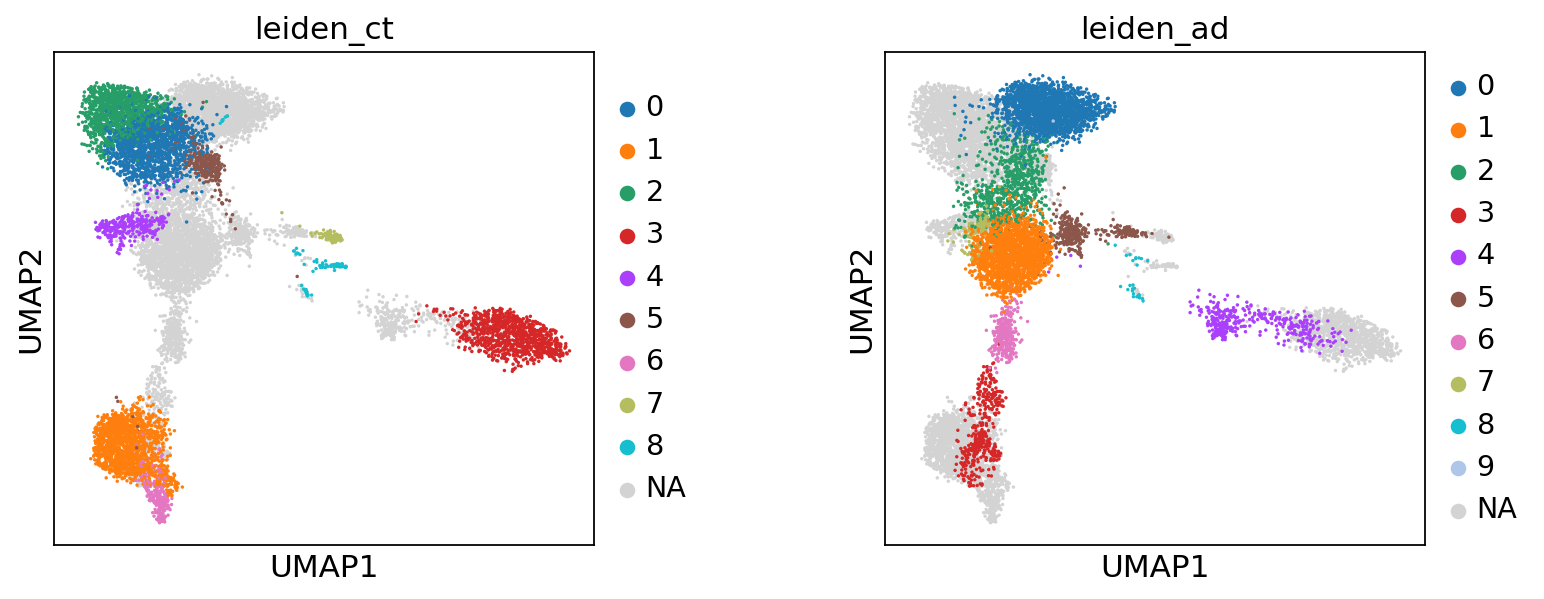

In [ ]:
# Creating clusters specific to 'ct' subgroup
sc.pp.neighbors(adata_ct, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(adata_ct, key_added='leiden_ct')
sc.tl.umap(adata_ct)

# Creating clusters specific to 'AD' subgroup
sc.pp.neighbors(adata_ad, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(adata_ad, key_added='leiden_ad')
sc.tl.umap(adata_ad)

# Putting new categories back in obs
adata.obs.loc[adata_ct.obs_names, 'leiden_ct'] = adata_ct.obs['leiden_ct']
adata.obs.loc[adata_ad.obs_names, 'leiden_ad'] = adata_ad.obs['leiden_ad']

sc.pl.umap(adata, color = ['leiden_ct', 'leiden_ad'], wspace = 0.4)

In [ ]:
# Rank genes within this subset
adata_ct = adata[adata.obs['oupSample.batchCond']=='ct'].copy()
sc.tl.rank_genes_groups(adata_ct, groupby='leiden_ct', method='t-test', use_raw=True)

adata_ad = adata[adata.obs['oupSample.batchCond']=='AD'].copy()
sc.tl.rank_genes_groups(adata_ad, groupby='leiden_ad', method='t-test', use_raw=True)

sc.pl.rank_genes_groups(adata_ct, n_genes=25)
sc.pl.rank_genes_groups(adata_ad, n_genes=25)

In [ ]:
# Plot a dotplot with the clusters specific to their subgroups
adata.obs['combined'] = adata.obs['leiden_ct'].astype(str) + "_" + adata.obs['leiden_ad'].astype(str)

sc.pl.dotplot(adata, markers, groupby='combined')